## 1. Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

df = pd.read_csv('results/final_analysis.csv')

print('\n--- Data Overview ---')
print('Shape:', df.shape)
display(df.head())
print('\nColumns:')
print(df.columns.tolist())
print('\nDtypes:')
print(df.dtypes)
display(df.sample(min(5, len(df))))


--- Data Overview ---
Shape: (204, 21)


,dish_id,calories,protein,fats,carbs,sugars,saturated_fats,salt,fiber,ingredients_number,...,dish_size,unit,price,category,location,ingredients,energy (kJ),veg_fruit_percentage,nutriscore_points,nutriscore_grade
0,1,947.46,35.80,59.26,71.00,12.23,12.91,2.63,8.00,12,...,350,NaN,45.99,Menu główne,Warszawa_Świętokrzyska,"rostbef, owoc kaparowca, cebula, ogórek kiszon...",226.45,34.29,21,E
1,2,827.85,10.17,53.12,80.11,15.62,5.84,2.88,9.68,9,...,330,g,37.99,Menu główne,Warszawa_Świętokrzyska,"pomidor, cebula, ogórek kiszony, kiełki groszk...",197.86,69.70,14,D
2,3,690.72,8.34,48.98,55.38,13.68,7.00,1.49,5.40,4,...,125,g,29.99,Menu główne,Warszawa_Świętokrzyska,"chipsy z batata, parmezan, sos AïOLI",165.09,72.00,10,C
3,4,300.45,6.37,22.42,19.44,10.53,6.13,11.04,6.33,7,...,300,g,32.99,Menu główne,Warszawa_Świętokrzyska,"grillowana kapusta, sambal, kremowy serek, oli...",71.81,83.33,19,E
4,5,1466.04,53.41,122.62,33.68,1.71,21.41,6.62,2.34,11,...,450,g,39.99,Menu główne,Warszawa_Świętokrzyska,"skrzydełka z kurczaka w pikantnej tempurze, so...",350.39,3.33,29,E



Columns:
['dish_id', 'calories', 'protein', 'fats', 'carbs', 'sugars', 'saturated_fats', 'salt', 'fiber', 'ingredients_number', 'dish_name', 'dish_size', 'unit', 'price', 'category', 'location', 'ingredients', 'energy (kJ)', 'veg_fruit_percentage', 'nutriscore_points', 'nutriscore_grade']

Dtypes:
dish_id                   int64
calories                float64
protein                 float64
fats                    float64
carbs                   float64
sugars                  float64
saturated_fats          float64
salt                    float64
fiber                   float64
ingredients_number        int64
dish_name                   str
dish_size                 int64
unit                        str
price                   float64
category                    str
location                    str
ingredients                 str
energy (kJ)             float64
veg_fruit_percentage    float64
nutriscore_points         int64
nutriscore_grade            str
dtype: object


,dish_id,calories,protein,fats,carbs,sugars,saturated_fats,salt,fiber,ingredients_number,...,dish_size,unit,price,category,location,ingredients,energy (kJ),veg_fruit_percentage,nutriscore_points,nutriscore_grade
162,163,1447.35,65.32,92.13,87.26,3.71,20.46,7.83,7.23,18,...,600,g,79.99,Menu główne,Katowice,"set 3 tapasów: AïOLI BEEF TATAR 2.0, TEMPURA C...",345.92,25.83,27,E
3,4,300.45,6.37,22.42,19.44,10.53,6.13,11.04,6.33,7,...,300,g,32.99,Menu główne,Warszawa_Świętokrzyska,"grillowana kapusta, sambal, kremowy serek, oli...",71.81,83.33,19,E
63,64,1184.92,61.52,72.46,71.26,4.95,24.08,10.09,5.11,14,...,570,g,129.99,Menu główne,Warszawa_Chmielna,"set 3 tapasów: BUTTER WINE SHRIMPS, BLACK GARL...",283.20,8.60,27,E
107,108,1466.04,53.41,122.62,33.68,1.71,21.41,6.62,2.34,11,...,450,g,39.99,Menu główne,Gdańsk,"skrzydełka z kurczaka w pikantnej tempurze, so...",350.39,3.33,29,E
171,172,1341.55,43.34,65.28,146.52,11.65,9.13,9.08,12.04,12,...,550,g,47.99,Menu główne,Katowice,"bułka pszenna, pierś z kurczaka w chrupiącej p...",320.64,54.00,25,E


In [2]:
print(f'There are {df.shape[0]} rows and {df.shape[1]} columns in the dataset & {df['dish_name'].nunique()} unique dishes on the menu.')

There are 204 rows and 21 columns in the dataset & 52 unique dishes on the menu.


## 2. Data Cleaning


--- Data Cleaning ---
Duplicates of whole row: 0
Gaps in dish_name: 0
Gaps in price: 0
Gaps in nutriscore_grade: 0


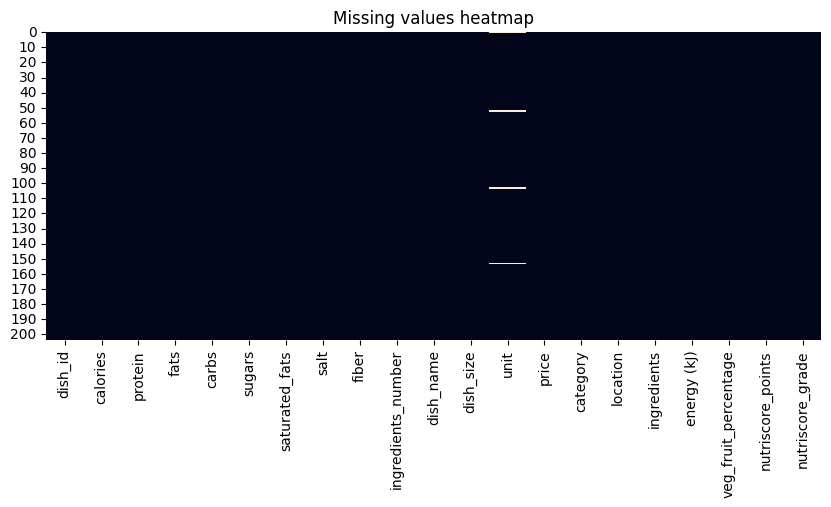

In [3]:
if df is not None:
    print('\n--- Data Cleaning ---')
    dup_count = df.duplicated().sum()
    print(f'Duplicates of whole row: {dup_count}')

    if dup_count > 0:
        df = df.drop_duplicates().reset_index(drop=True)
        print(f'{dup_count} duplicates removed')

    key_cols = ['dish_name','price', 'nutriscore_grade']
    for c in key_cols:
        if c in df.columns:
            miss = df[c].isna().sum()
            print(f'Gaps in {c}: {miss}')

plt.figure(figsize=(10,4))
sns.heatmap(df.isna(), cbar=False)
plt.title('Missing values heatmap')
plt.show()

In [4]:
print(f'Gapis in unit column: {(df['unit'].isna().sum()/len(df)) * 100}%')

Gapis in unit column: 1.9607843137254901%


## 3. Data Exploration

there are some missing information in the Unit column, but they should not interfere with the analysis.

In [5]:
print('\n--- Statistics numeric columns: ---')
display(df.describe())
print('\n--- Statistics text columns: ---')
display(df.describe(include='object'))


--- Statistics numeric columns: ---


,dish_id,calories,protein,fats,carbs,sugars,saturated_fats,salt,fiber,ingredients_number,dish_size,price,energy (kJ),veg_fruit_percentage,nutriscore_points
count,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000
mean,102.500000,736.853578,28.560441,45.064118,54.389804,6.942451,12.442647,5.938775,5.042843,9.539216,318.666667,49.999804,176.112402,39.138676,19.156863
std,59.033889,448.505918,19.739627,31.437554,37.651141,8.594588,8.479667,5.610743,3.639587,2.884207,184.161759,22.918573,107.195172,49.097070,9.572894
min,1.000000,66.030000,2.800000,2.680000,7.170000,0.370000,0.870000,0.290000,0.430000,4.000000,28.000000,22.990000,15.780000,0.000000,0.000000
25%,51.750000,438.310000,8.340000,26.530000,23.680000,1.920000,5.840000,1.490000,2.250000,7.000000,190.000000,34.990000,104.760000,13.160000,14.000000
50%,102.500000,710.230000,27.640000,41.450000,47.590000,4.180000,11.270000,4.940000,4.250000,9.000000,340.000000,45.990000,169.750000,25.450000,23.000000
75%,153.250000,1015.400000,43.545000,64.350000,75.020000,8.670000,19.977500,9.080000,7.230000,12.000000,450.000000,52.990000,242.687500,50.000000,26.250000
max,204.000000,1740.640000,72.780000,132.500000,146.520000,48.810000,34.450000,30.500000,17.940000,18.000000,620.000000,145.990000,416.020000,263.160000,31.000000



--- Statistics text columns: ---


C:\Users\48668\AppData\Local\Temp\ipykernel_14344\3291462285.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include='object'))


,dish_name,unit,category,location,ingredients,nutriscore_grade
count,204,200,204,204,204,204
unique,52,4,2,4,53,5
top,AïOLI BEEF TATAR 2.0,g,Menu główne,Warszawa_Świętokrzyska,"rostbef, owoc kaparowca, cebula, ogórek kiszon...",E
freq,4,148,160,52,4,131


In [6]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print()

dish_id
[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204]

calories
[ 947.46  827.85  690.72  300.45 1466.04  631.5   493.25  493.17  438.31
 1447.35 1740.64 1184.92  375.02  159.34 1420.43  688.15 1509.45 1245.1
 1341.55

In [7]:
print(f'Weights of dishes on the menu: {df['dish_size'].unique()}')
print(f'\nMinumum weight of a dish on the menu: {df['dish_size'].unique().min()}')
print(f'\nMaximum weight of a dish on the menu: {df['dish_size'].unique().max()}')

Weights of dishes on the menu: [350 330 125 300 450 225 220 230 600 540 570 520 310 550  38 420 525 500
 190 390 380 364 620 360 370  28 340 400 430 315 385]

Minumum weight of a dish on the menu: 28

Maximum weight of a dish on the menu: 620


In [8]:
df[df['dish_size'] == df['dish_size'].unique().min()]

,dish_id,calories,protein,fats,carbs,sugars,saturated_fats,salt,fiber,ingredients_number,...,dish_size,unit,price,category,location,ingredients,energy (kJ),veg_fruit_percentage,nutriscore_points,nutriscore_grade
41,42,66.03,2.8,2.91,7.17,0.38,0.87,0.29,0.43,8,...,28,cm,32.99,Śniadania,Warszawa_Świętokrzyska,"ciasto z mąki włoskiej, sos na bazie pomidorów...",15.78,21.43,0,A
42,43,764.35,29.9,33.05,87.18,4.90,9.66,2.92,5.13,7,...,28,cm,28.99,Śniadania,Warszawa_Świętokrzyska,"ciasto z mąki włoskiej, sos na bazie pomidorów...",182.68,250.00,15,D
92,93,66.03,2.8,2.91,7.17,0.38,0.87,0.29,0.43,8,...,28,cm,32.99,Śniadania,Warszawa_Chmielna,"ciasto z mąki włoskiej, sos na bazie pomidorów...",15.78,21.43,0,A
93,94,764.35,29.9,33.05,87.18,4.90,9.66,2.92,5.13,7,...,28,cm,28.99,Śniadania,Warszawa_Chmielna,"ciasto z mąki włoskiej, sos na bazie pomidorów...",182.68,250.00,15,D
142,143,66.03,2.8,2.91,7.17,0.38,0.87,0.29,0.43,8,...,28,cm,32.99,Śniadania,Gdańsk,"ciasto z mąki włoskiej, sos na bazie pomidorów...",15.78,21.43,0,A
143,144,764.35,29.9,33.05,87.18,4.90,9.66,2.92,5.13,7,...,28,cm,28.99,Śniadania,Gdańsk,"ciasto z mąki włoskiej, sos na bazie pomidorów...",182.68,250.00,15,D
193,194,66.03,2.8,2.91,7.17,0.38,0.87,0.29,0.43,8,...,28,cm,32.99,Śniadania,Katowice,"ciasto z mąki włoskiej, sos na bazie pomidorów...",15.78,21.43,0,A
194,195,764.35,29.9,33.05,87.18,4.90,9.66,2.92,5.13,7,...,28,cm,28.99,Śniadania,Katowice,"ciasto z mąki włoskiej, sos na bazie pomidorów...",182.68,250.00,15,D


Strange minimum size is because it is pizza and is measured in cm.

In [9]:
df[df['dish_size'] == df['dish_size'].unique().max()]

,dish_id,calories,protein,fats,carbs,sugars,saturated_fats,salt,fiber,ingredients_number,...,dish_size,unit,price,category,location,ingredients,energy (kJ),veg_fruit_percentage,nutriscore_points,nutriscore_grade
38,39,991.6,34.1,69.13,60.7,10.74,16.03,3.54,8.62,9,...,620,G,34.99,Menu główne,Warszawa_Świętokrzyska,"sałata rzymska, pomidorki cherry, grzanki, Gra...",237.0,46.77,23,E
90,91,991.6,34.1,69.13,60.7,10.74,16.03,3.54,8.62,9,...,620,G,34.99,Menu główne,Warszawa_Chmielna,"sałata rzymska, pomidorki cherry, grzanki, Gra...",237.0,46.77,23,E
140,141,991.6,34.1,69.13,60.7,10.74,16.03,3.54,8.62,9,...,620,G,34.99,Menu główne,Gdańsk,"sałata rzymska, pomidorki cherry, grzanki, Gra...",237.0,46.77,23,E
191,192,991.6,34.1,69.13,60.7,10.74,16.03,3.54,8.62,9,...,620,G,34.99,Menu główne,Katowice,"sałata rzymska, pomidorki cherry, grzanki, Gra...",237.0,46.77,23,E


It looks suspicious that the salad weighs so much and is the heaviest on the entire menu, but I checked the menu and it is indeed served that way.

In [10]:
df['location'].value_counts()

location
Warszawa_Świętokrzyska    52
Warszawa_Chmielna         51
Katowice                  51
Gdańsk                    50
Name: count, dtype: int64

Dataset is balanced, there is almost the same number of dishes across locations.

In [11]:
price_comparison = df.pivot_table(values='price', index='dish_name',columns='location', aggfunc='mean')
missing_dishes = price_comparison[price_comparison.isnull().any(axis=1)]
print(f"Number of dishes not available at all locations: {len(missing_dishes)}")
missing_dishes.head()

Number of dishes not available at all locations: 2


location,Gdańsk,Katowice,Warszawa_Chmielna,Warszawa_Świętokrzyska
dish_name,,,,
ASIAN CHICKEN BOWL,NaN,NaN,NaN,39.99
HACHE STEAK,NaN,75.99,75.99,75.99


Asian Chicken Bowl is only available in Warsaw Świętokrzyska, and Hatche Steak is not available in Gdańsk. 
Besides that, the dishes offered are the same at each location.

In [12]:
inconsistent = price_comparison[price_comparison.nunique(axis=1) > 1]
print(f"Dishes with different prices across locations: {len(inconsistent)}")
inconsistent.head()

Dishes with different prices across locations: 1


location,Gdańsk,Katowice,Warszawa_Chmielna,Warszawa_Świętokrzyska
dish_name,,,,
AïOLI SEASONAL STEAK,95.99,145.99,145.99,145.99


Prices for individual dishes are the same in all locations except one - Seasonal Steak is much cheaper in Gdańsk than in other cities. 

In [13]:
print('Most expensive dishes on the menu:')
df.groupby('dish_name')['price'].max().nlargest(10).reset_index()

Most expensive dishes on the menu:


,dish_name,price
0,AïOLI SEASONAL STEAK,145.99
1,AïOLI SHARING SEAFOOD,129.99
2,SURF & TURF 2.0,97.99
3,GREEN PEPPER STEAK,89.99
4,CLASSIC NY STEAK,85.99
5,AïOLI SHARING MEAT,79.99
6,HACHE STEAK,75.99
7,AïOLI SHARING VEGE,59.99
8,PHILLY CHEESESTEAK BURGER,59.99
9,TAGLIOLINI & SHRIMPS,56.99


Steaks are most expensive dishes on the menu.

In [14]:
print('Cheapest dishes on the menu:')
df.groupby('dish_name')['price'].max().nsmallest(10).reset_index()

Cheapest dishes on the menu:


,dish_name,price
0,CREMA DI POMODORO,22.99
1,ZUPA DNIA,22.99
2,AïOLI BREAKKIE PIZZA VEGE,28.99
3,SWEET POTATO CHIPS,29.99
4,TRUFFLE SCRAMBLE TOAST,29.99
5,AïOLI BREAKKIE PIZZA,32.99
6,ROASTED CABBAGE,32.99
7,TURKISH EGGS,32.99
8,AVOCADO TOAST,34.99
9,BACON SANDWICH,34.99


Breakfasts are the cheapest on the menu.

In [15]:
df[df['dish_name'] == 'ZUPA DNIA']

,dish_id,calories,protein,fats,carbs,sugars,saturated_fats,salt,fiber,ingredients_number,...,dish_size,unit,price,category,location,ingredients,energy (kJ),veg_fruit_percentage,nutriscore_points,nutriscore_grade
13,14,159.34,3.89,8.91,16.48,4.09,1.23,4.22,4.0,6,...,450,ml,22.99,Menu główne,Warszawa_Świętokrzyska,"zapytaj kelnera, jaką zupę przygotował dzisiaj...",38.08,27.11,19,E
65,66,159.34,3.89,8.91,16.48,4.09,1.23,4.22,4.0,6,...,450,ml,22.99,Menu główne,Warszawa_Chmielna,"zapytaj kelnera, jaką zupę przygotował dzisiaj...",38.08,27.11,19,E
116,117,159.34,3.89,8.91,16.48,4.09,1.23,4.22,4.0,6,...,450,ml,22.99,Menu główne,Gdańsk,"zapytaj kelnera, jaką zupę przygotował dzisiaj...",38.08,27.11,19,E
166,167,159.34,3.89,8.91,16.48,4.09,1.23,4.22,4.0,6,...,450,ml,22.99,Menu główne,Katowice,"zapytaj kelnera, jaką zupę przygotował dzisiaj...",38.08,27.11,19,E


'ZUPA DNIA' is not real dish so should be deleted.

In [16]:
df = df[df['dish_name'] != 'ZUPA DNIA']

In [17]:
print(f'Min number of ingredients in a dish: {df['ingredients_number'].unique().min()}')
print(f'Max number of ingredients in a dish: {df['ingredients_number'].unique().max()}')

Min number of ingredients in a dish: 4
Max number of ingredients in a dish: 18


In [18]:
df[df['ingredients_number'] == 31]

,dish_id,calories,protein,fats,carbs,sugars,saturated_fats,salt,fiber,ingredients_number,...,dish_size,unit,price,category,location,ingredients,energy (kJ),veg_fruit_percentage,nutriscore_points,nutriscore_grade


31 ingredients seems suspicious but it is a sharing meat with small portions of different kind of meats so it makes sense there are so many components.

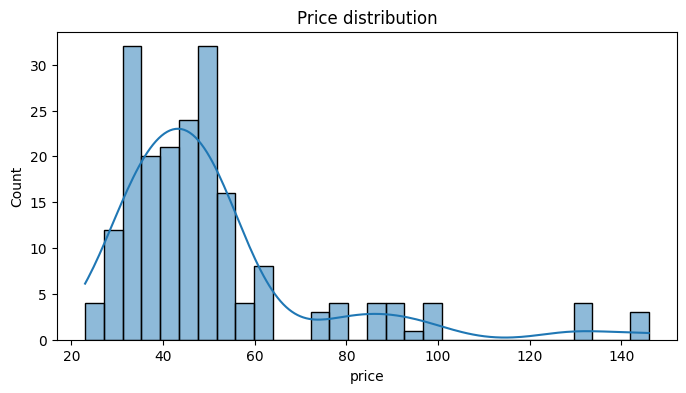

In [19]:
plt.figure(figsize=(8,4))
sns.histplot(df['price'], bins=30, kde=True)
plt.title('Price distribution')
plt.show()

Most dishes are priced between 30–55 PLN, making it an affordable menu. A few premium outliers reach up to 145 PLN, but these are rare exceptions.

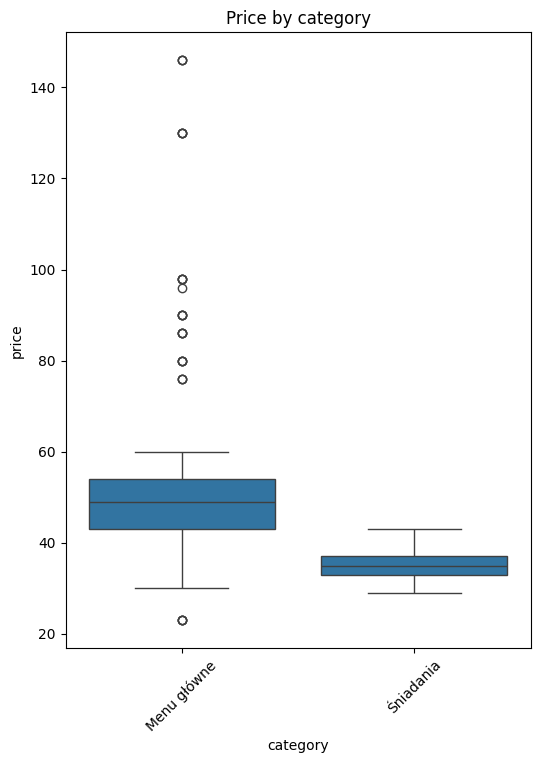

In [20]:
plt.figure(figsize=(6,8))
sns.boxplot(data = df, x='category', y='price')
plt.xticks(rotation=45)
plt.title('Price by category')
plt.show()

Main dishes are more expensive than breakfasts.

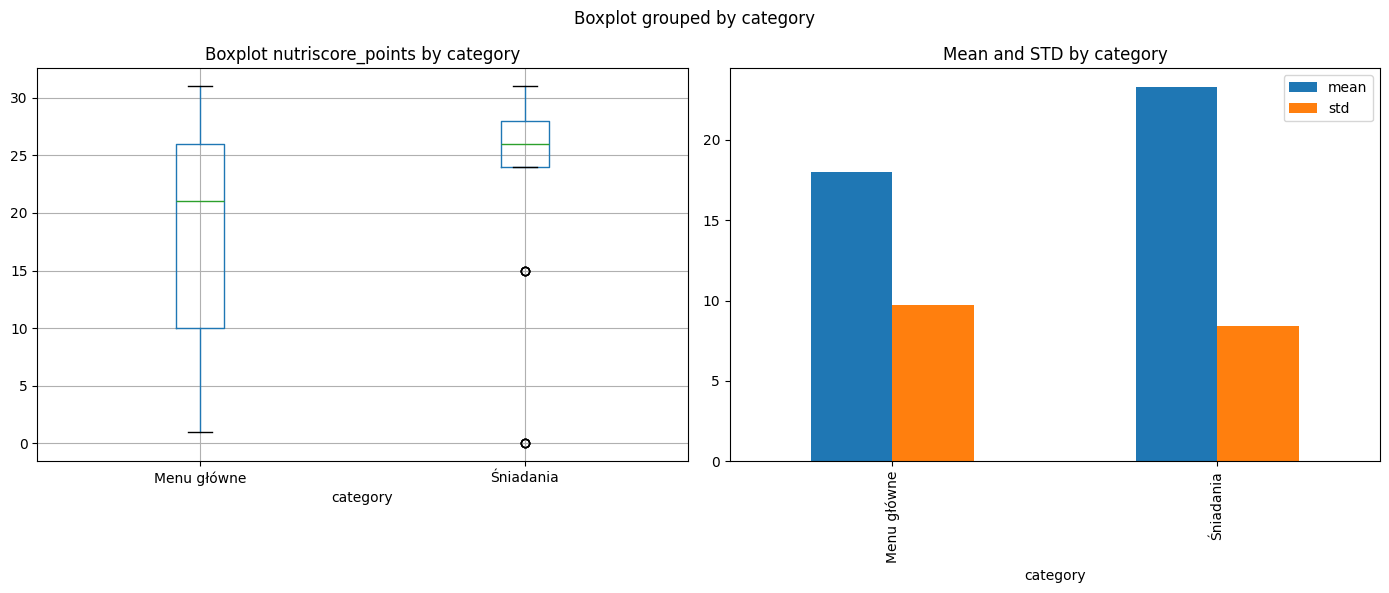

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

df.boxplot(column='nutriscore_points',by='category', ax=axes[0])
axes[0].set_title("Boxplot nutriscore_points by category")

stats = df.groupby('category')['nutriscore_points'].describe()[['mean', 'std']]
stats.plot(kind='bar', ax=axes[1])

axes[1].set_title("Mean and STD by category")

plt.tight_layout()
plt.show()

Breakfasts are slightly healthier and more consistent than the main dishes, which have some notably unhealthy outliers.

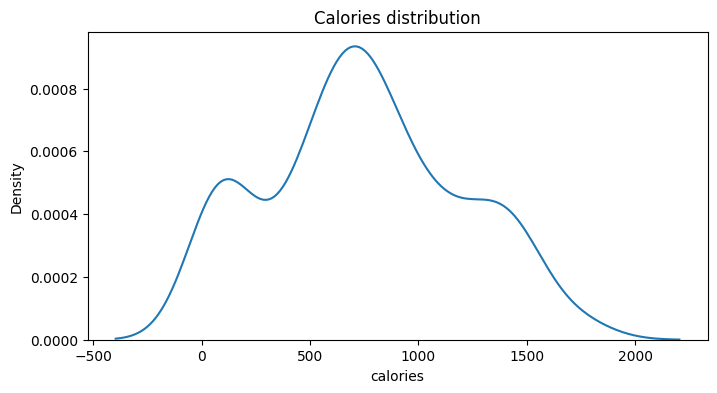

In [22]:
plt.figure(figsize=(8,4))
sns.kdeplot(df['calories'].dropna())
plt.title('Calories distribution')
plt.show()

In [23]:
print('The most caloric dishes:')
df.drop_duplicates(subset='dish_name').nlargest(5, 'calories')[['dish_name', 'calories']]

The most caloric dishes:


,dish_name,calories
10,AïOLI SHARING VEGE,1740.64
16,PHILLY CHEESESTEAK BURGER,1509.45
4,TEMPURA CRISPY WINGS,1466.04
9,AïOLI SHARING MEAT,1447.35
14,AïOLI BURGER,1420.43


Pizzas are most caloric dishes on the menu.

In [24]:
print('The least caloric dishes')
df.drop_duplicates(subset='dish_name').nsmallest(5, 'calories')[['dish_name', 'calories']]

The least caloric dishes


,dish_name,calories
41,AïOLI BREAKKIE PIZZA,66.03
21,BURRATA & COTTO,80.69
23,TARTUFO & COTTO BIANCA,81.67
19,MARGHERITA,84.72
25,KIMCHI PIZZA,88.73


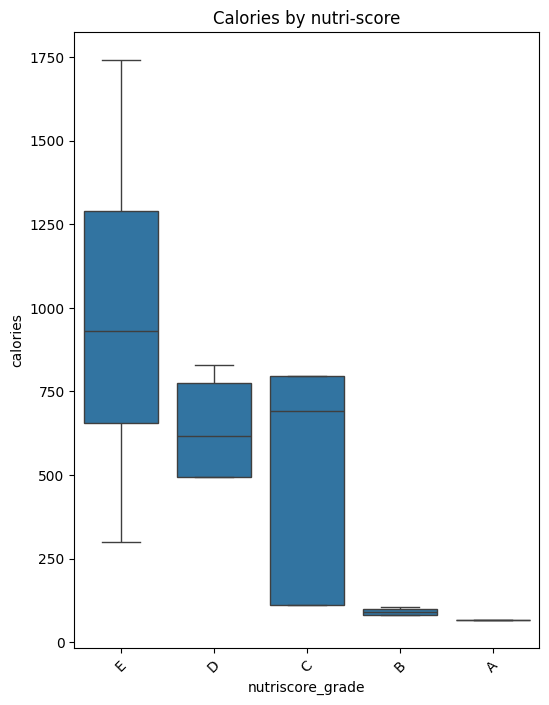

In [25]:
plt.figure(figsize=(6,8))
sns.boxplot(data = df, x='nutriscore_grade', y='calories')
plt.xticks(rotation=45)
plt.title('Calories by nutri-score')
plt.show()

Dishes with the worst nutritional grade (E) tend to have the most calories - around 1000 on average, sometimes even reaching 1600. The healthier grades are much lighter, mostly sitting around 600–700 calories. Grade B seems to be the lowest in calories, but there are very few such dishes on the menu.

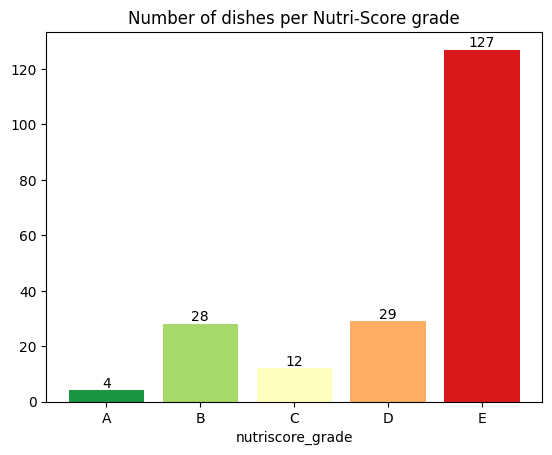

In [26]:
order = ['A', 'B', 'C', 'D', 'E']
colors = ['#1a9641', '#a6d96a', '#ffffbf', '#fdae61', '#d7191c']
color_map = dict(zip(order, colors))

counts = df['nutriscore_grade'].value_counts()
counts = counts.reindex(order) #.fillna(0)

fig, ax = plt.subplots()
bars = ax.bar(counts.index, counts.values, color=colors)

for bar in bars:
    height = bar.get_height()
    ax.annotate(int(height),
                xy=(bar.get_x() + bar.get_width() / 2, height),
                ha='center', va='bottom')

plt.title('Number of dishes per Nutri-Score grade')
plt.xlabel('nutriscore_grade')
plt.show()

Most of the Aioli's dishes have a very poor nutri-score, and the entire menu performs poorly. Let's see how it compares at individual locations.

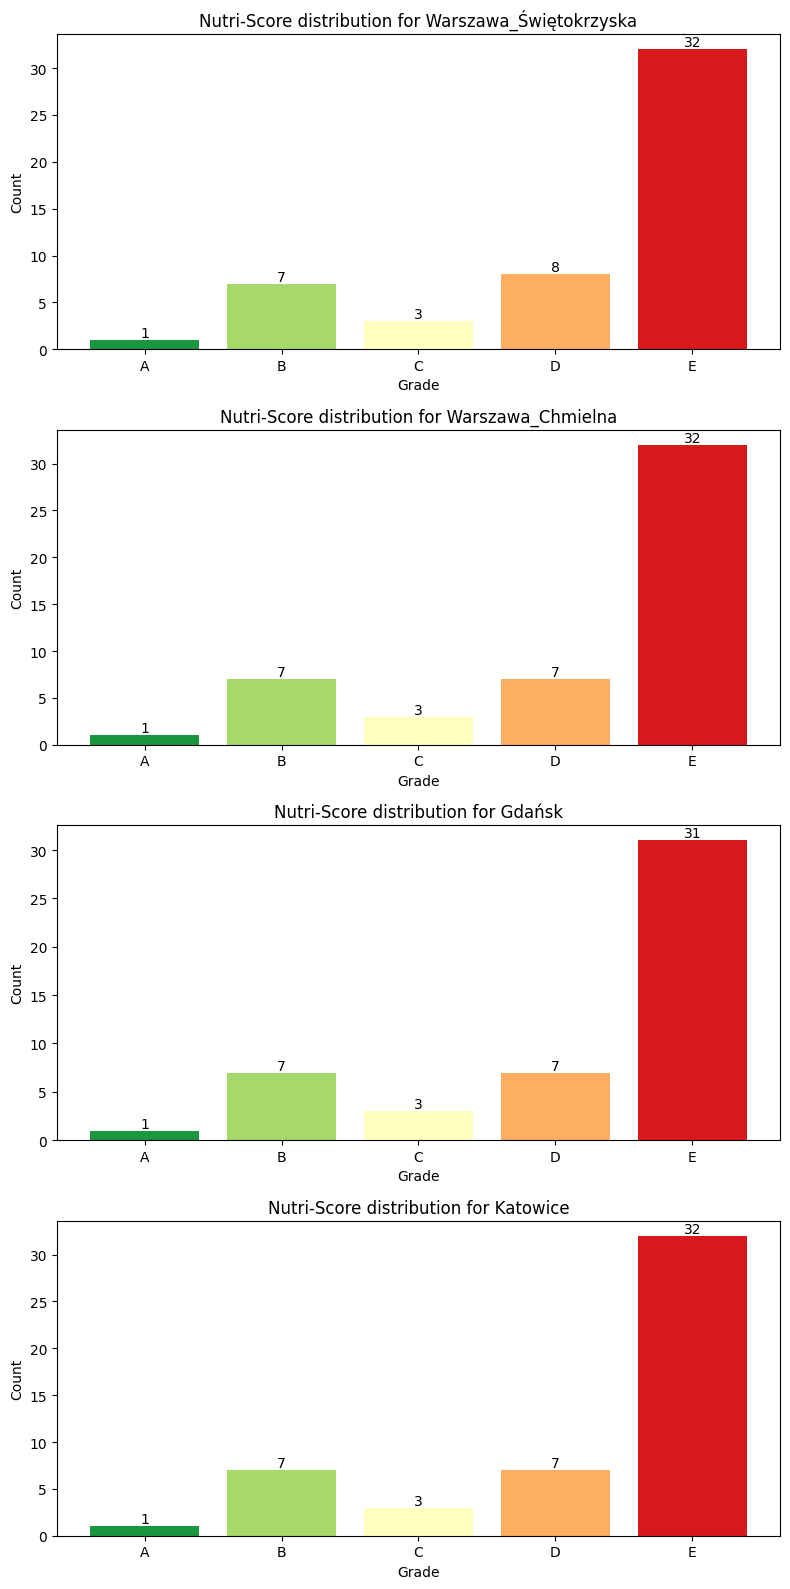

In [27]:
cities = df['location'].unique()

fig, axes = plt.subplots(len(cities), 1, figsize=(8, 4 * len(cities)))
axes = np.atleast_1d(axes).flatten()

for ax, city in zip(axes, cities):
    counts = (df.loc[df['location'] == city, 'nutriscore_grade']
                .value_counts()
                .reindex(order)
                .fillna(0))
    
    bar_colors = [color_map[g] for g in counts.index]
    bars = ax.bar(counts.index, counts.values, color=bar_colors)
    
    for bar in bars:
        height = bar.get_height()
        ax.annotate(int(height),
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    ha='center', va='bottom')
    
    ax.set_title(f'Nutri-Score distribution for {city}')
    ax.set_xlabel('Grade')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

We now know that the poor nutritional rating isn't due to one location, but overall, this chain offers meals that aren't very nutritious.

In [28]:
print('Average dish prices per nutri-score grade:')
print(df.groupby('nutriscore_grade')['price'].median().round(2))

Average dish prices per nutri-score grade:
nutriscore_grade
A    32.99
B    48.99
C    38.99
D    44.99
E    45.99
Name: price, dtype: float64


strangely enough, there is no correlation between the high nutri score and the price.

In [29]:
print('Top 5 healthiest dishes:')
df.nsmallest(5, 'nutriscore_points')[['dish_name', 'nutriscore_grade', 'calories']]

Top 5 healthiest dishes:


,dish_name,nutriscore_grade,calories
41,AïOLI BREAKKIE PIZZA,A,66.03
92,AïOLI BREAKKIE PIZZA,A,66.03
142,AïOLI BREAKKIE PIZZA,A,66.03
193,AïOLI BREAKKIE PIZZA,A,66.03
19,MARGHERITA,B,84.72


In [30]:
print('Top 5 healthiest dishes:')
df.nsmallest(5, 'nutriscore_points')[['dish_name', 'nutriscore_grade', 'calories']]

Top 5 healthiest dishes:


,dish_name,nutriscore_grade,calories
41,AïOLI BREAKKIE PIZZA,A,66.03
92,AïOLI BREAKKIE PIZZA,A,66.03
142,AïOLI BREAKKIE PIZZA,A,66.03
193,AïOLI BREAKKIE PIZZA,A,66.03
19,MARGHERITA,B,84.72


## 4. Correlations & Relationships

In [31]:
numeric_cols = [col for col in df.select_dtypes(include='number').columns if col != 'dish_id']
outliers = {}
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    outliers[col] = df[(df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)]

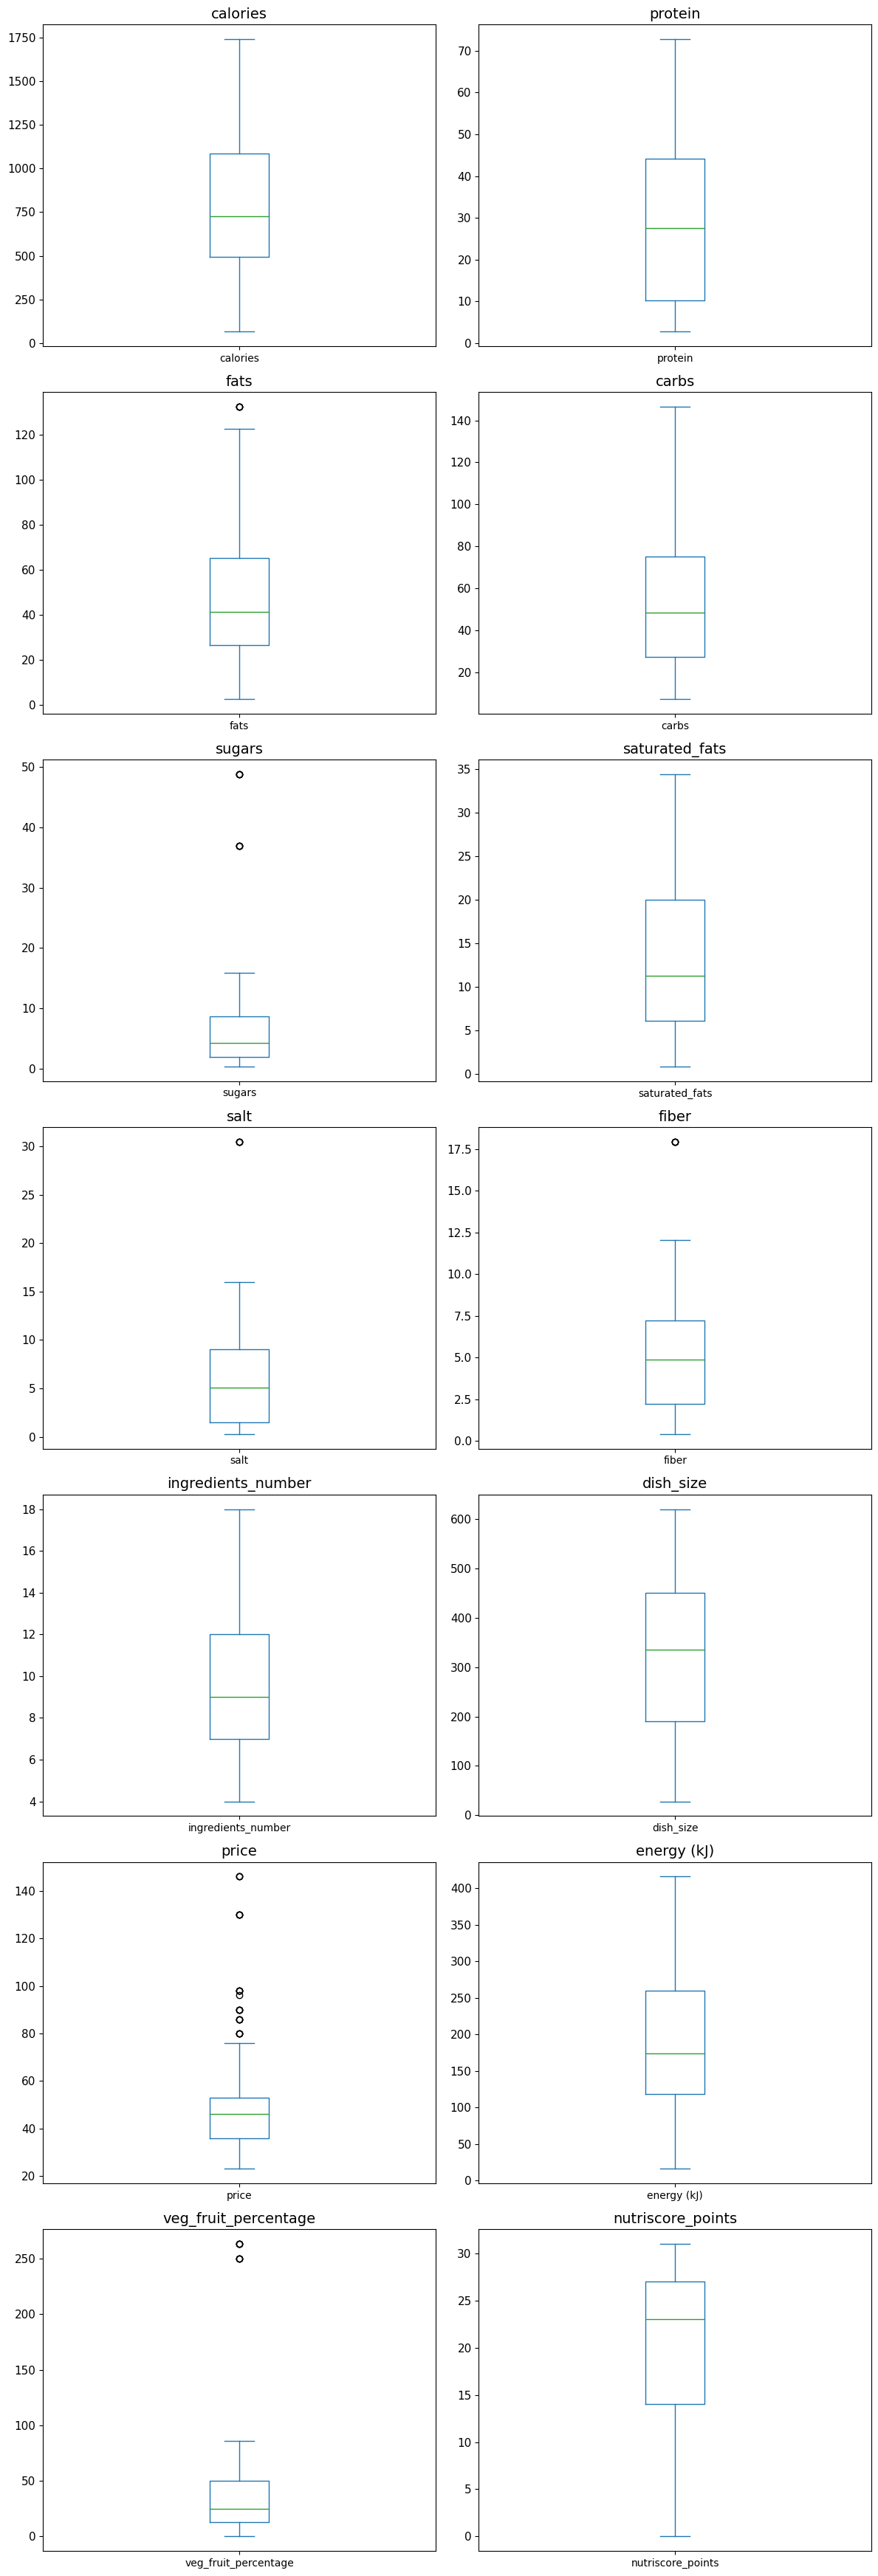

In [32]:
n_cols = 2
n_rows = math.ceil(len(numeric_cols) / 2)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    df[col].plot.box(ax=ax)
    ax.set_title(col, fontsize=14)
    ax.tick_params(axis='y', labelsize=11)

for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

- Calories -> wide spread, median ~800 kcal. High variability between dishes.
- Protein -> median ~32g, some dishes reach 75g, likely meat-heavy meals(?).
- Fats -> median ~45g, a few outliers above 120g.
- Carbs -> median ~55g, max up to 165g.
- Sugars -> mostly low (~5g), outliers up to 65g, which is strange as we have no desserts in the dataset.
- Saturated fats -> median ~14g, one extreme outlier at ~40g.
- Salt -> median ~3g, one dish reaches 18g — unusually salty.
- Fiber -> stable, median ~6g, small spread.
- Ingredients number -> typically 8–13 ingredients per dish.
- Dish size -> median ~325g, wide range from very small to 600g+ (but we already know it is Cesar Salad and it is correct).
- Price -> median ~45 PLN, some premium dishes up to 145 PLN.
- Energy (kJ) -> consistent with calories, median ~200 kJ.
- Veg/fruit percentage -> wide range, from dishes with no vegetables at all to very plant-heavy ones.
- Nutri-score -> median ~22 pts, a few dishes score below 0, indicating very poor nutritional quality.

In [33]:
df['dish_name'][df['protein']>45].unique()

<StringArray>
[     'TEMPURA CRISPY WINGS',        'AïOLI SHARING MEAT',
     'AïOLI SHARING SEAFOOD',              'AïOLI BURGER',
 'PHILLY CHEESESTEAK BURGER',          'PROSCIUTTO CRUDO',
      'AïOLI SEASONAL STEAK',          'CLASSIC NY STEAK',
        'GREEN PEPPER STEAK',           'SURF & TURF 2.0',
               'HACHE STEAK',            'BACON SANDWICH']
Length: 12, dtype: str

High protein dishes are naturally steaks, burgers, seafood platters, and meat-heavy breakfasts. No data errors here, outliers make sense.

In [34]:
df['dish_name'][df['fats']>80].unique()

<StringArray>
[     'TEMPURA CRISPY WINGS',        'AïOLI SHARING MEAT',
        'AïOLI SHARING VEGE',              'AïOLI BURGER',
 'PHILLY CHEESESTEAK BURGER',           'SURF & TURF 2.0',
         'ENGLISH BREAKFAST']
Length: 7, dtype: str

Also makes sense — sharing platters, burgers, sandwiches, and full breakfasts are naturally high in fat.

In [35]:
df['dish_name'][df['sugars']>20].unique()

<StringArray>
['AïOLI SHARING VEGE', 'SYRNIKI VANILLA & RHUBARB']
Length: 2, dtype: str

SYRNIKI - sweet breakfast makes total sense for high sugar. VEGE TATAR is surprising though — worth checking what ingredients drive the sugar up.

In [36]:
df[df['dish_name']=='AïOLI VEGE TATAR']

,dish_id,calories,protein,fats,carbs,sugars,saturated_fats,salt,fiber,ingredients_number,...,dish_size,unit,price,category,location,ingredients,energy (kJ),veg_fruit_percentage,nutriscore_points,nutriscore_grade
1,2,827.85,10.17,53.12,80.11,15.62,5.84,2.88,9.68,9,...,330,g,37.99,Menu główne,Warszawa_Świętokrzyska,"pomidor, cebula, ogórek kiszony, kiełki groszk...",197.86,69.7,14,D
53,54,827.85,10.17,53.12,80.11,15.62,5.84,2.88,9.68,9,...,330,g,37.99,Menu główne,Warszawa_Chmielna,"pomidor, cebula, ogórek kiszony, kiełki groszk...",197.86,69.7,14,D
104,105,827.85,10.17,53.12,80.11,15.62,5.84,2.88,9.68,9,...,330,g,37.99,Menu główne,Gdańsk,"pomidor, cebula, ogórek kiszony, kiełki groszk...",197.86,69.7,14,D
154,155,827.85,10.17,53.12,80.11,15.62,5.84,2.88,9.68,9,...,330,g,37.99,Menu główne,Katowice,"pomidor, cebula, ogórek kiszony, kiełki groszk...",197.86,69.7,14,D


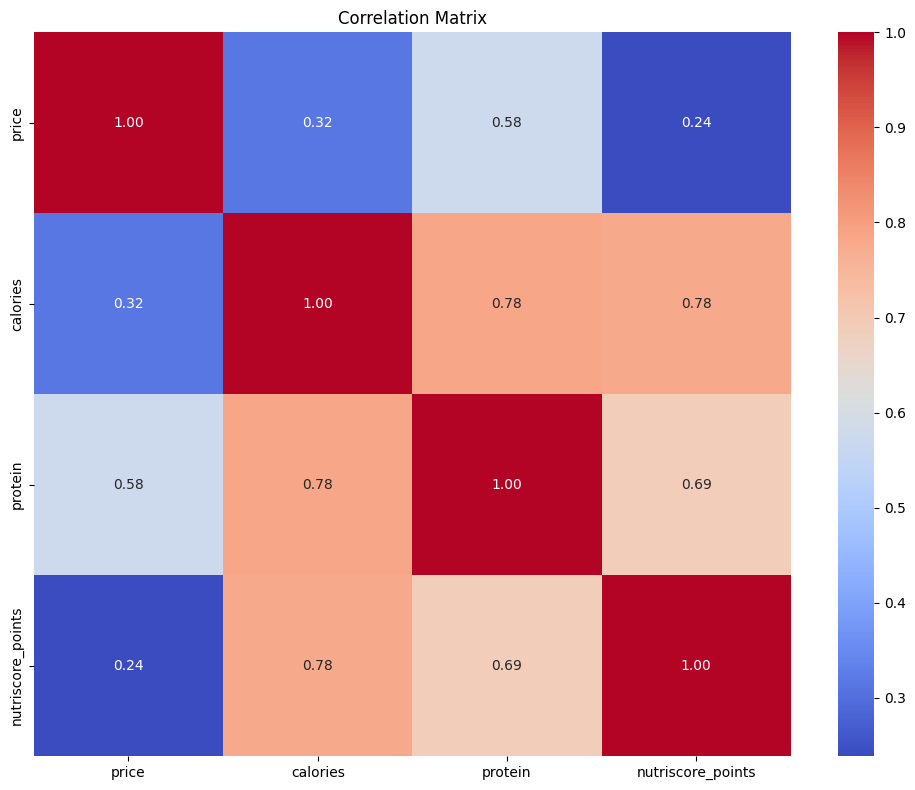

In [37]:
corr = df[['price','calories','protein','nutriscore_points']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

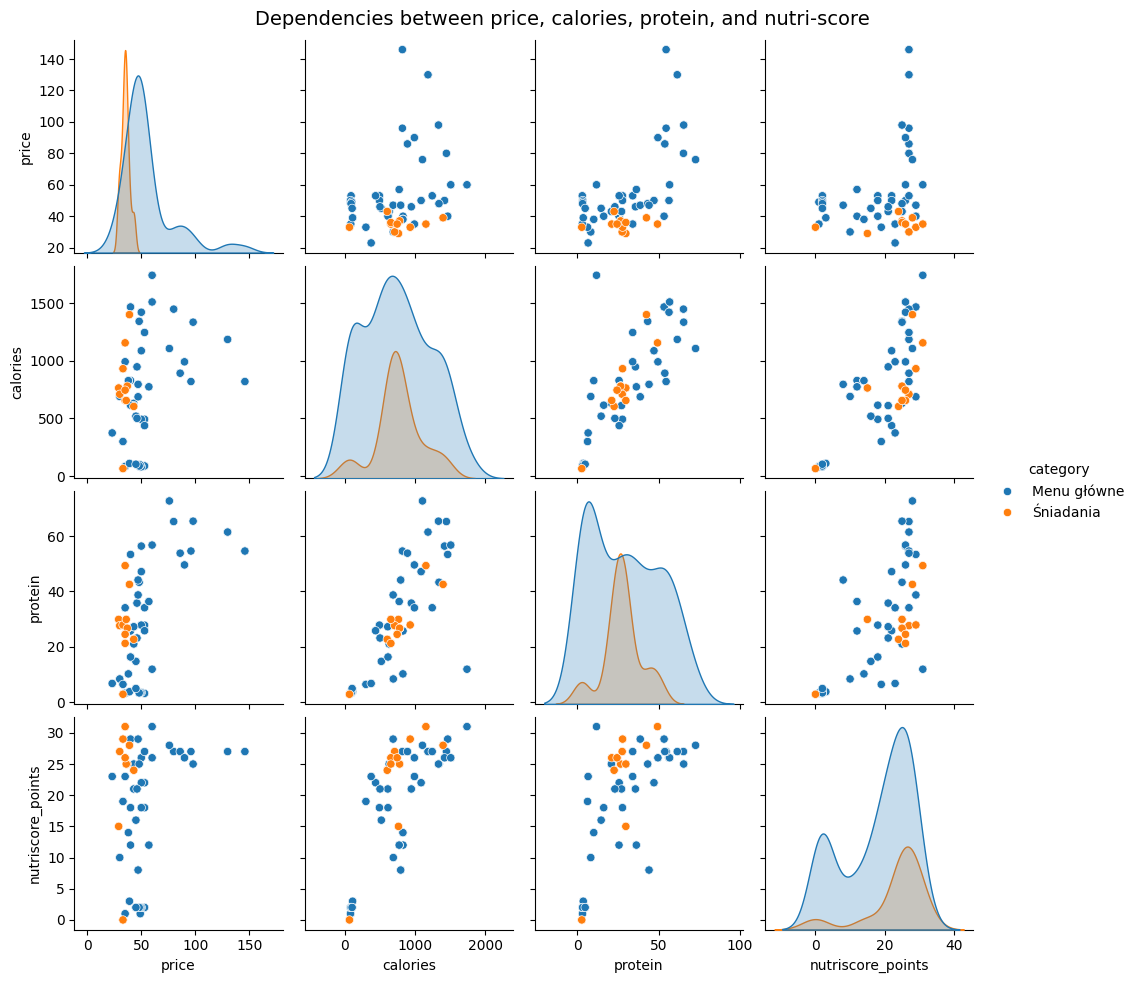

In [38]:
g = sns.pairplot(df[['price', 'calories', 'protein', 'nutriscore_points','category']], hue ='category')
g.figure.subplots_adjust(top=0.95)
g.figure.suptitle('Dependencies between price, calories, protein, and nutri-score', fontsize=14)
plt.show()

- Breakfasts are cheaper and healthier.
- Main dishes calorie distribution has two peaks (~600 and ~1000 kcal), which suggests two groups -> lighter and heavier meals. Breakfasts stay mostly in the 400–800 kcal range.
- Higher calorie dishes tend to have more protein. Main menu items can reach up to 70g, while breakfasts usually stay below 30g.
- There is no clear link between price and nutri-score — expensive dishes are not necessarily better for you.

# 5. Conclusions

- The dataset is clean and consistent — the menu is nearly identical across all 4 locations, and prices match everywhere (one exception: Aïoli Seasonal Steak, cheaper in Gdańsk).
- The menu is affordable overall, with most dishes priced 30–55 PLN; steaks and sharing platters are the premium outliers.
- There is **no correlation between price and nutri-score** — paying more does not mean eating healthier.
- Overall nutritional quality is poor: the majority of dishes score grade **E**, and this pattern holds consistently across all locations — it's a chain-wide characteristic, not a single-restaurant issue.
- A worse nutri-score correlates with higher calories (grade E dishes average ~1000 kcal, sometimes reaching 1600+).
- Breakfasts are cheaper, lighter, and healthier (better and more consistent nutri-score) than main dishes.
- Main dish calories show a bimodal distribution (~600 and ~1000 kcal), suggesting two distinct groups: lighter and heavier meals.
- Higher-calorie dishes tend to have more protein, which is expected given they are mostly steaks, burgers, and seafood platters — no data errors found among the outliers.

**Bottom line:** the menu is budget-friendly but nutritionally weak. There is room to introduce healthier options (more fiber/vegetables, less saturated fat) without needing to change the pricing strategy.